In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("cleaned_dataset_sample.csv")

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df = df.sort_values('date')

In [5]:
df.set_index('date', inplace=True)

In [6]:
print(df.head())

           symbol    open   high      low   close    volume
date                                                       
2014-01-02     cf  46.606  47.36  46.4588  46.738   3460110
2014-01-02      c  52.030  52.40  51.8100  52.270  16489767
2014-01-02    ctl  31.740  31.82  31.5100  31.650   4446283
2014-01-02    cms  26.800  26.80  26.2050  26.300   2218229
2014-01-03   andv  57.470  58.02  56.4200  57.140   2744311


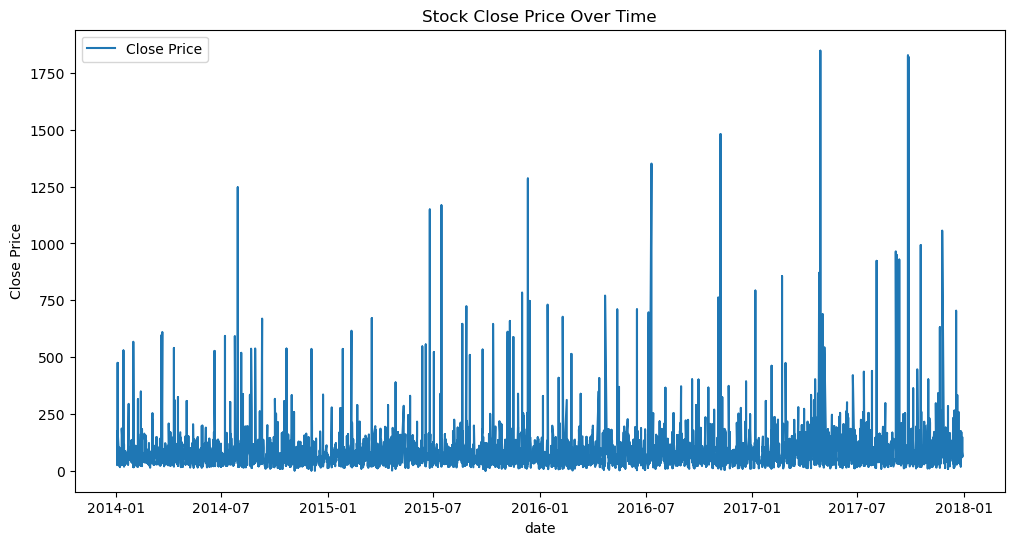

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Close Price')
plt.title("Stock Close Price Over Time")
plt.xlabel("date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

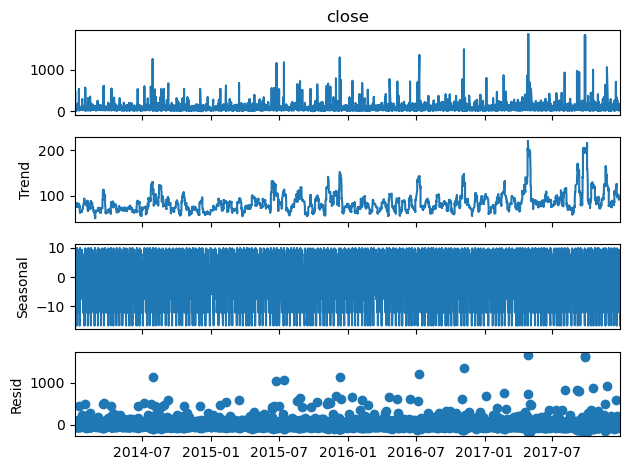

In [8]:
decomposition = seasonal_decompose(
    df['close'],
    model='additive',
    period=30
)

decomposition.plot()
plt.show()

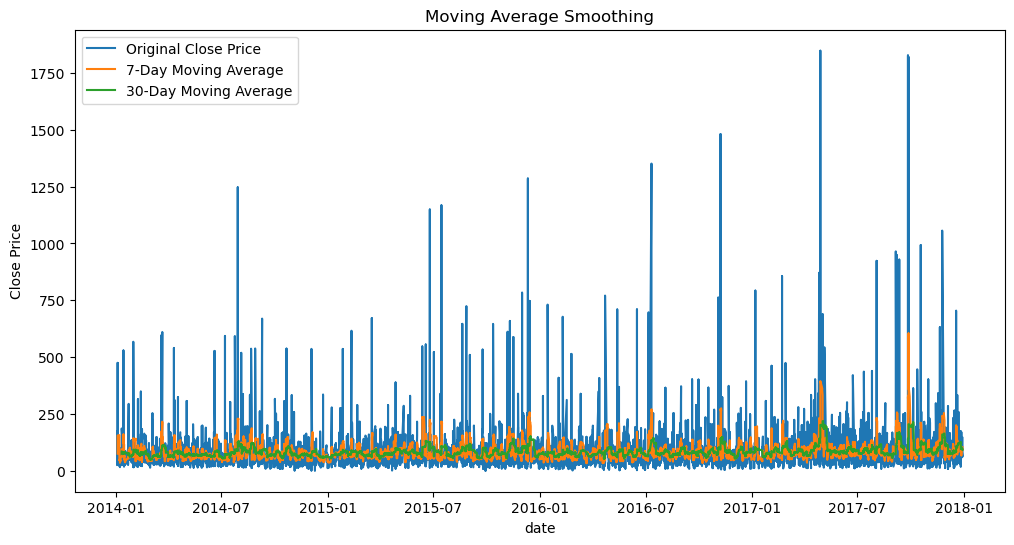

In [9]:
df['MA_7'] = df['close'].rolling(window=7).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Original Close Price')
plt.plot(df['MA_7'], label='7-Day Moving Average')
plt.plot(df['MA_30'], label='30-Day Moving Average')
plt.title("Moving Average Smoothing")
plt.xlabel("date")
plt.ylabel("Close Price")
plt.legend()
plt.show()